In [ ]:
import pandas as pd

df = pd.read_csv('crime_dataset_india.csv')

print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Report Number     Date Reported Date of Occurrence Time of Occurrence  \
0              1  02-01-2020 00:00   01-01-2020 00:00   01-01-2020 01:11   
1              2  01-01-2020 19:00   01-01-2020 01:00   01-01-2020 06:26   
2              3  02-01-2020 05:00   01-01-2020 02:00   01-01-2020 14:30   
3              4  01-01-2020 05:00   01-01-2020 03:00   01-01-2020 14:46   
4              5  01-01-2020 21:00   01-01-2020 04:00   01-01-2020 16:51   

        City  Crime Code Crime Description  Victim Age Victim Gender  \
0  Ahmedabad         576    IDENTITY THEFT          16             M   
1    Chennai         128          HOMICIDE          37             M   
2   Ludhiana         271        KIDNAPPING          48             F   
3       Pune         170          BURGLARY          49             F   
4       Pune         421         VANDALISM          30             F   

    Weapon Used   Crime Domain  Police Deployed Case Closed  Date Case Closed  
0

Saving crime_dataset_india.csv to crime_dataset_india (2).csv
Dataset Loaded Successfully!
Shape: (40160, 14)

Columns:
 Index(['Report Number', 'Date Reported', 'Date of Occurrence',
       'Time of Occurrence', 'City', 'Crime Code', 'Crime Description',
       'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain',
       'Police Deployed', 'Case Closed', 'Date Case Closed'],
      dtype='object')

First 5 Rows:
    Report Number     Date Reported Date of Occurrence Time of Occurrence  \
0              1  02-01-2020 00:00   01-01-2020 00:00   01-01-2020 01:11   
1              2  01-01-2020 19:00   01-01-2020 01:00   01-01-2020 06:26   
2              3  02-01-2020 05:00   01-01-2020 02:00   01-01-2020 14:30   
3              4  01-01-2020 05:00   01-01-2020 03:00   01-01-2020 14:46   
4              5  01-01-2020 21:00   01-01-2020 04:00   01-01-2020 16:51   

        City  Crime Code Crime Description  Victim Age Victim Gender  \
0  Ahmedabad         576    IDENTITY THEFT    

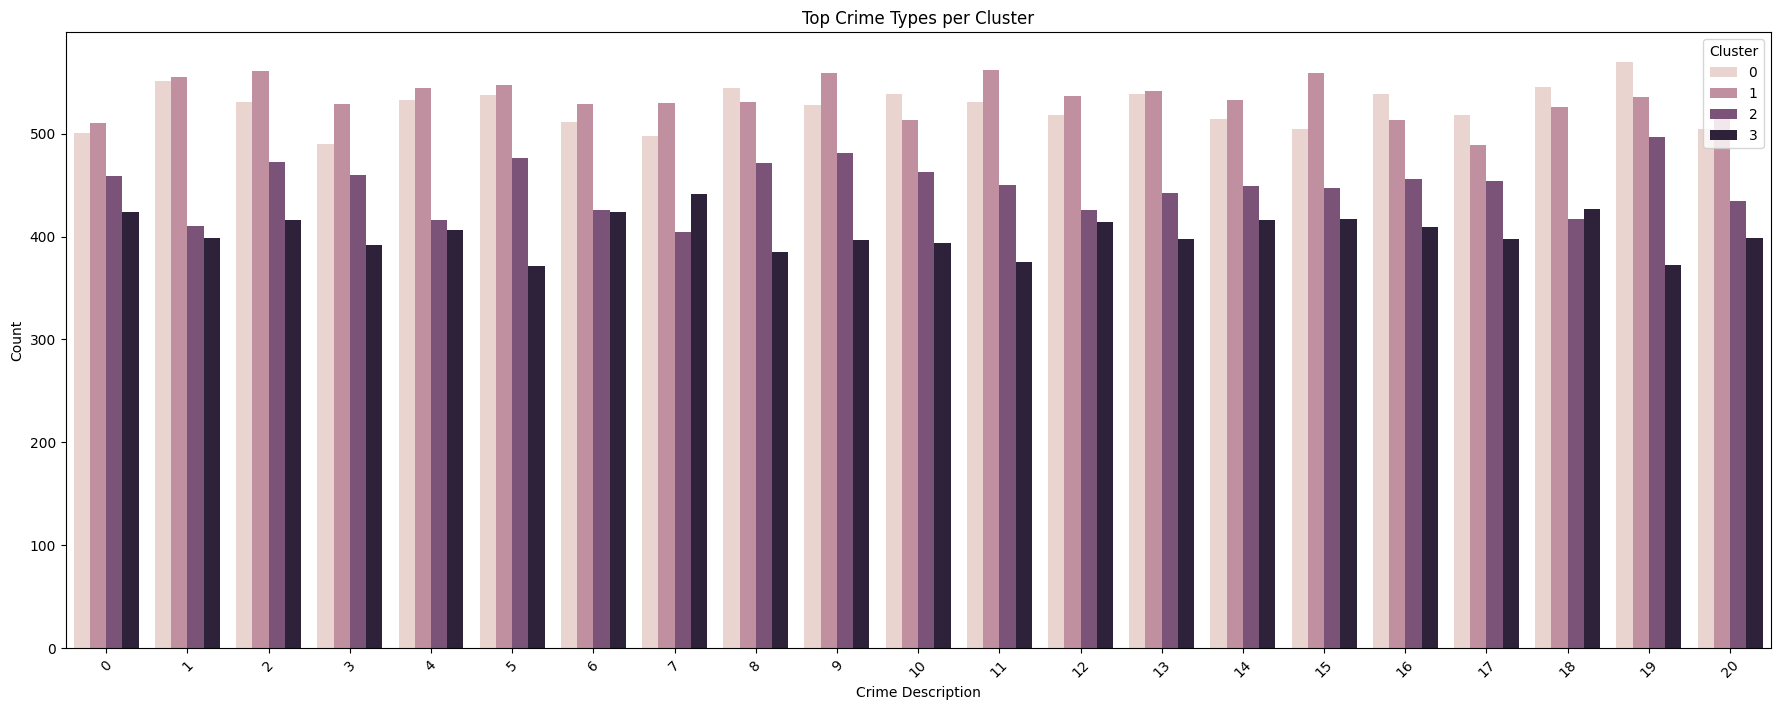


🔹 Cluster 0 - Pattern Summary
Top Cities: [5, 17, 2]
Top Crimes: [19, 1, 18]
Victim Genders: {0: 6085, 1: 3712, 2: 1251}

🔹 Cluster 1 - Pattern Summary
Top Cities: [5, 17, 2]
Top Crimes: [11, 2, 9]
Victim Genders: {0: 6094, 1: 3728, 2: 1405}

🔹 Cluster 2 - Pattern Summary
Top Cities: [5, 17, 2]
Top Crimes: [19, 9, 5]
Victim Genders: {0: 5857, 1: 3107, 2: 447}

🔹 Cluster 3 - Pattern Summary
Top Cities: [5, 17, 2]
Top Crimes: [7, 18, 6]
Victim Genders: {0: 4387, 1: 2858, 2: 1229}


In [ ]:
# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Load Dataset
# -----------------------------
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('crime_dataset_india.csv')

# -----------------------------
# Clean Column Names
# -----------------------------
df.columns = df.columns.str.strip()

# -----------------------------
# Display Basic Info
# -----------------------------
print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 Rows:\n", df.head())

# -----------------------------
# Encode Text Columns
# -----------------------------
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# -----------------------------
# KMeans Clustering
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)

# -----------------------------
# Crime Occurrence by Hour
# -----------------------------
if 'Hour' in df.columns:
    plt.figure(figsize=(12,6))
    sns.countplot(x='Hour', data=df)
    plt.title("Crime Occurrence by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("Crime Count")
    plt.show()
else:
    print("Hour column not found.")

# -----------------------------
# Top Crime Types per Cluster
# -----------------------------
if 'Crime Description' in df.columns:
    plt.figure(figsize=(22,8))
    sns.countplot(x='Crime Description', hue='Cluster', data=df)
    plt.title("Top Crime Types per Cluster")
    plt.xlabel("Crime Description")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Crime Description column not found.")

# -----------------------------
# Cluster Pattern Summary
# -----------------------------
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]

    print(f"\n🔹 Cluster {cluster} - Pattern Summary")

    if 'City' in df.columns:
        top_cities = cluster_data['City'].value_counts().head(3)
        print("Top Cities:", top_cities.index.tolist())

    if 'Crime Description' in df.columns:
        top_crimes = cluster_data['Crime Description'].value_counts().head(3)
        print("Top Crimes:", top_crimes.index.tolist())

    if 'Hour' in df.columns:
        peak_hours = cluster_data['Hour'].value_counts().head(3)
        print("Peak Hours:", peak_hours.index.tolist())

    if 'Weapon' in df.columns:
        top_weapons = cluster_data['Weapon'].value_counts().head(2)
        print("Weapons:", top_weapons.index.tolist())

    if 'Victim Gender' in df.columns:
        victim_gender = cluster_data['Victim Gender'].value_counts()
        print("Victim Genders:", victim_gender.to_dict())